# Loading Saved Models

This notebook demonstrates how to load and use saved model files using the qneural framework.

**Note**: These visualization functions use publication-quality formatting with LaTeX-style text (via matplotlib's mathtext) and 200 DPI resolution.

In [6]:
import torch
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add qneural to path
sys.path.insert(0, str(Path.cwd().parent))

from qneural.utils import load_saved_model
from qneural.analysis import plot_gate_time_vs_angle, plot_detuning_pulses

print("✓ Imports successful")

✓ Imports successful


## 1. Load a Saved Model (One Line!)

Available publication models:
- `5e-5pi_to_0.05pi.pt` - Very small angles
- `0.05pi_to_0.1pi.pt` - Small angles
- `pt1pi_to_pt3pi.pt` - Mid-range angles (0.1π to 0.3π)
- `pt3pi_to_pt5pi.pt` - Mid-range angles (0.3π to 0.5π)
- `pt5pi_to_pi.pt` - CZ gate (0.5π to π)

Use `load_saved_model()` to load everything in one line:

In [7]:
# Load a model - prints metadata and fidelity statistics automatically
model_path = "../qneural/data/publication_models/pt5pi_to_pi.pt"

controller, checkpoint = load_saved_model(
    model_path,
    print_metadata=True,  # Print model info, architecture, config
    evaluate_fidelity=True,  # Compute and print fidelity statistics
    n_eval_angles=50,  # Number of angles for fidelity evaluation
)

# Controller is now ready to use!
print("\n✓ Model loaded successfully!")

Model Metadata:
  source: archival_publication
  original_file: pt5pi_to_pi
  note: Publication-quality results for CZ gate (0.5π = π ...
  missing_data: ['training_history', 'epoch_count', 'optimizer_states']
  angle_range: [0.5000π, 1.0000π]
  angle_range_tensor: [0.5000π, 0.5000π]
  angle_range_source: network_attribute

Controller Configuration:
  Time network: 1 layers x 45 units (sigmoid)
  Control network: 9 layers x 300 units
  Time bounds: [0.1611, 0.3382] s
  Rabi max: 25.13 MHz
  Time steps: 201
  Total parameters: 723,737

Evaluating fidelity on 50 angles...

Fidelity Statistics:
  Mean: 99.9991%
  Min: 99.9982%
  Max: 99.9999%
  Std: 0.0004%
  All > 99%: True

✓ Model loaded successfully!


## 2. Visualize Results Using Analysis Functions

Use the built-in visualization functions from `qneural.analysis` which provide:
- Publication-quality formatting with LaTeX-style text
- 200 DPI resolution
- Mathtext for mathematical symbols (no LaTeX installation needed)


Generating gate time plot...


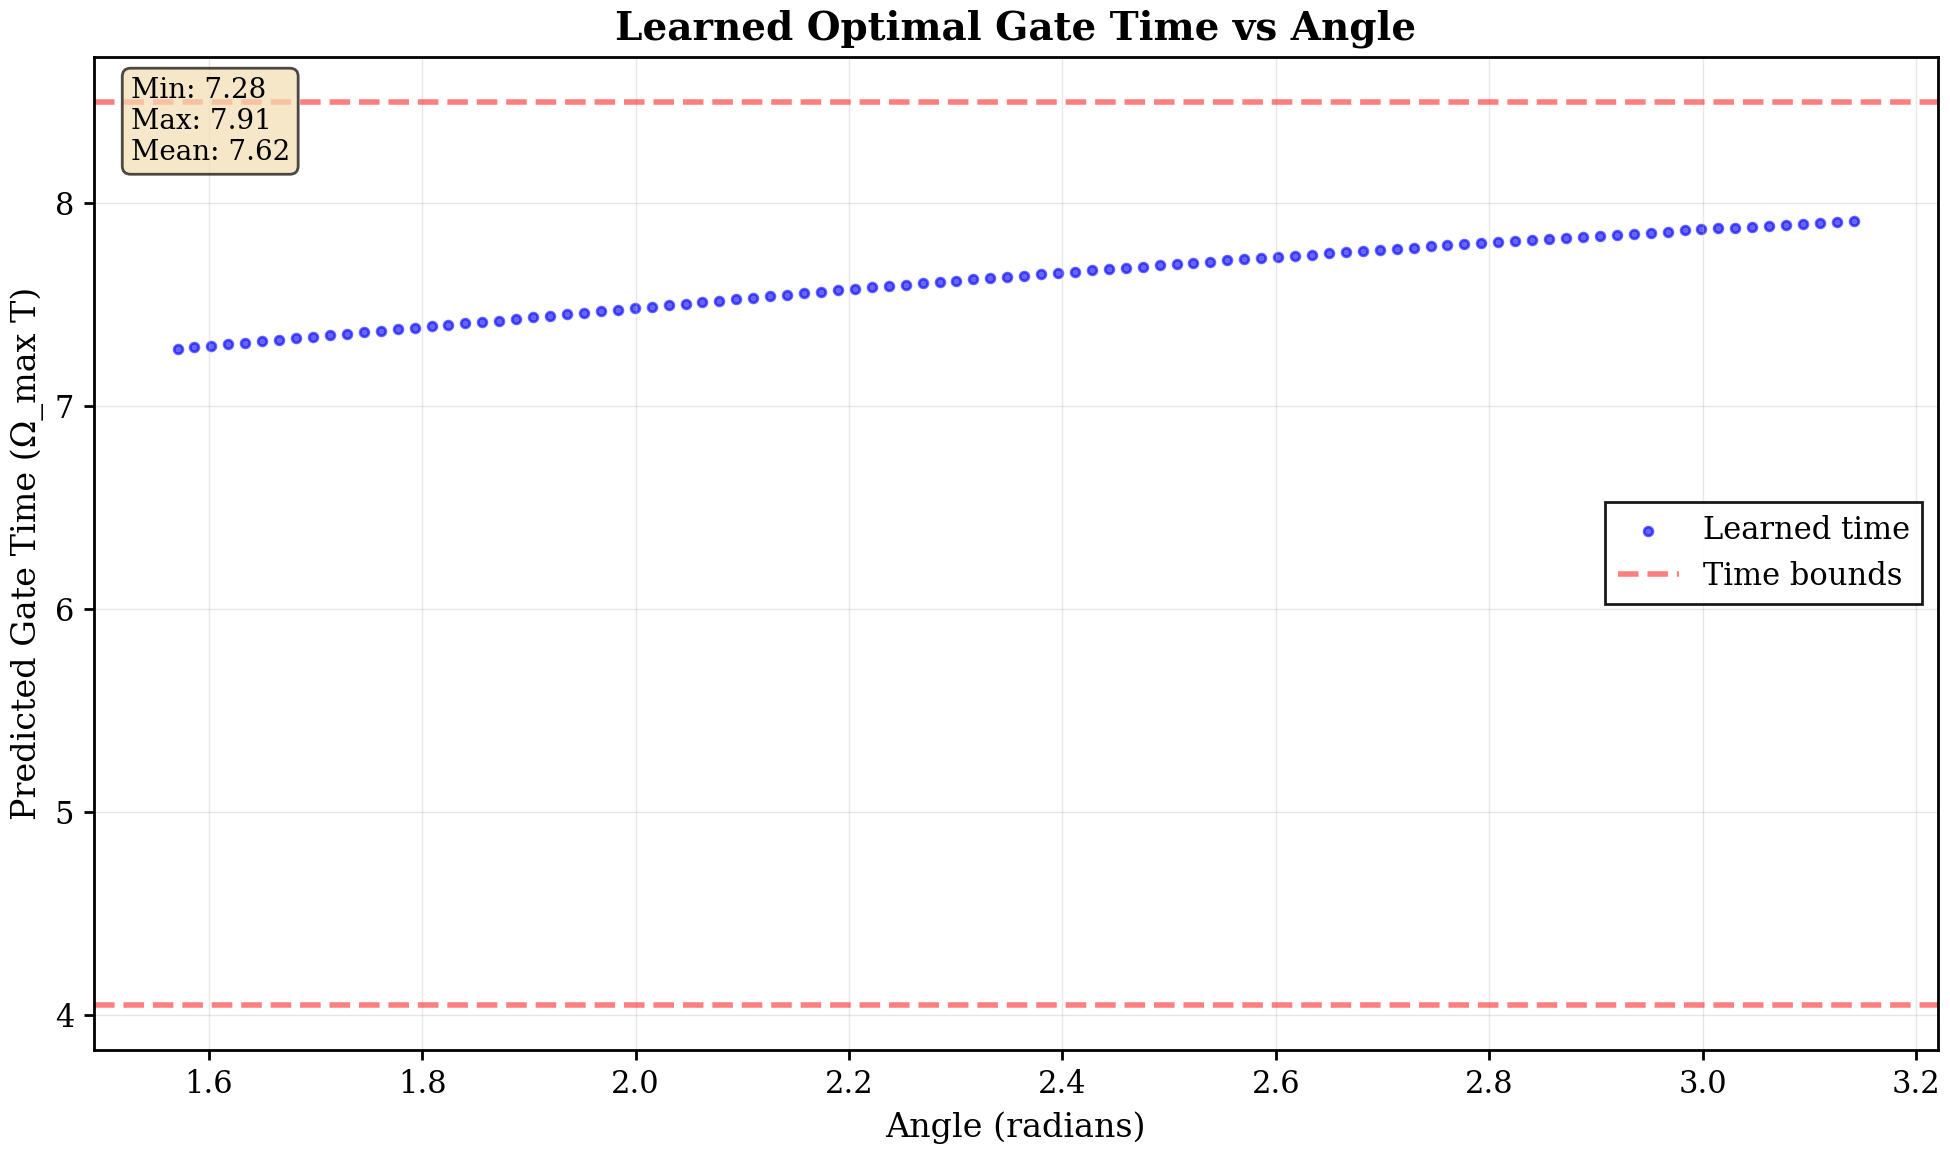

In [8]:
# Get configuration from checkpoint
config = checkpoint["controller_config"]
angle_range = checkpoint["metadata"]["angle_range"]

# Plot 1: Gate time vs angle (publication-quality formatting)
print("\nGenerating gate time plot...")
fig1 = plot_gate_time_vs_angle(
    controller,
    angle_range=(angle_range[0], angle_range[1]),
    n_angles=100,
    rabi_max=config["rabi_max"],
    time_bounds=(
        config["time_bounds"][0] * config["rabi_max"],
        config["time_bounds"][1] * config["rabi_max"],
    ),
    figsize=(10, 6),
    show=False,  # Prevent double display
)
plt.show()  # Display once

## 3. Visualize Detuning Pulses (All Angles on One Plot)

Plot pulses for multiple angles on a single figure with different colors.


Generating pulse visualization for 5 angles...


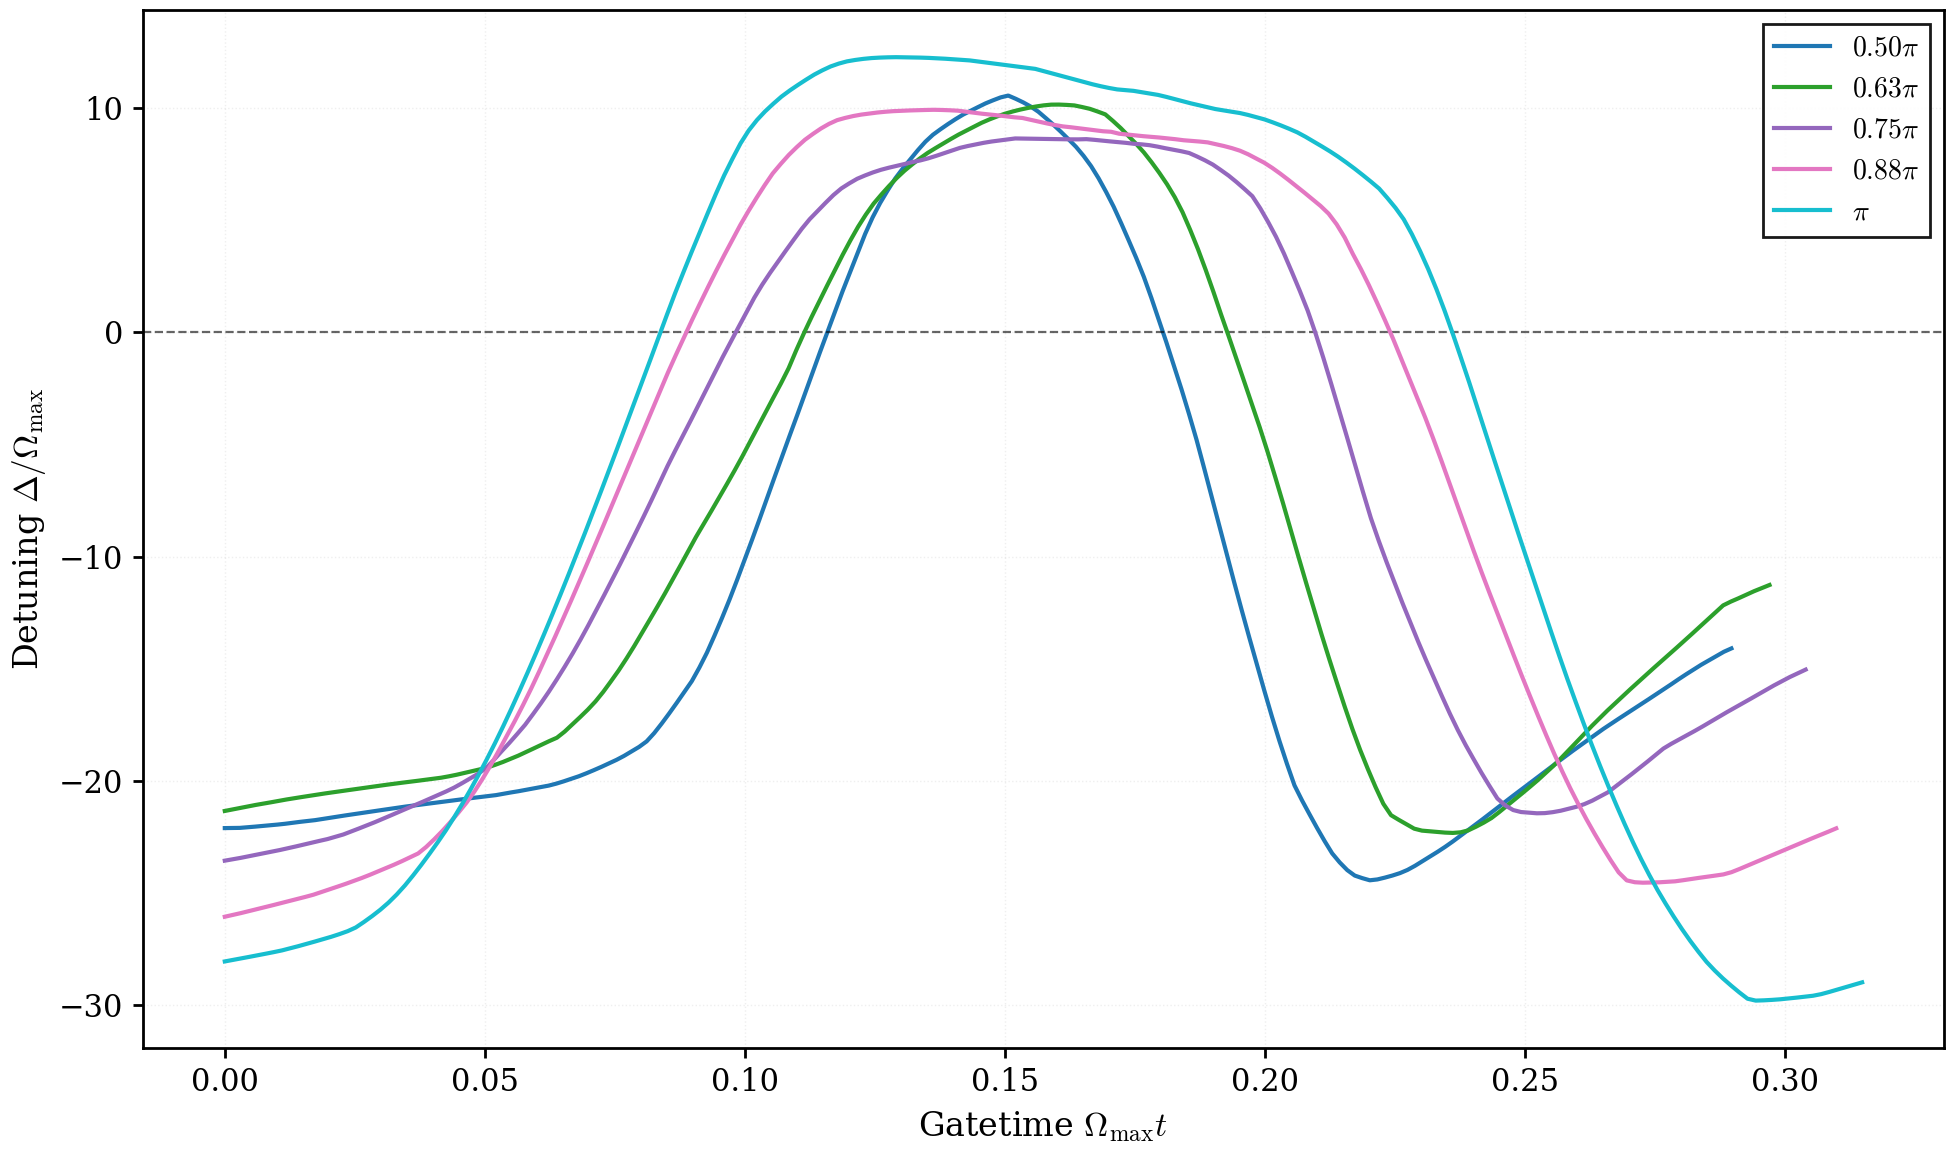

In [9]:
# Select angles to visualize
sample_angles = torch.linspace(angle_range[0], angle_range[1], 5)

print(f"\nGenerating pulse visualization for {len(sample_angles)} angles...")
fig2 = plot_detuning_pulses(
    controller,
    sample_angles,
    rabi_max=config["rabi_max"],
    single_plot=True,
    figsize=(10, 6),
    n_time_steps=config["n_time_steps"],
    show=False,  # Prevent double display
)
plt.show()  # Display once

## Summary

This notebook demonstrated the simplified workflow:

1. **One-line loading** - `controller, checkpoint = load_saved_model(path)`
2. **Automatic metadata display** - Model info, architecture, configuration
3. **Automatic fidelity evaluation** - Statistics computed and displayed
4. **Publication-quality visualization** - Using `qneural.analysis` functions

**Function signature:**
```python
controller, checkpoint = load_saved_model(
    model_path: str,          # Path to .pt file
    print_metadata: bool = True,      # Print model info
    evaluate_fidelity: bool = True,   # Compute fidelity stats
    n_eval_angles: int = 50,          # Number of angles for eval
    device: str = 'cpu'               # 'cpu' or 'cuda'
)
```

**Visualization features:**
- LaTeX-style text via matplotlib's mathtext (Computer Modern font)
- 200 DPI resolution for crisp figures
- Single-plot pulse visualization with color-coded angles

**Key points:**
- All models achieve >99% fidelity across their trained angle ranges
- Works with both converted archival models and newly trained models
- Missing: training history, epoch counts, optimizer states (not in original files)
- Available: Full trained weights, architecture, time bounds, angle ranges